In [1]:
df <- read.csv('/Users/arinapetushok/Documents/LSM2/airnbnb/Airbnb_Open_Data.csv')
head(df)

,id,NAME,host.id,host_identity_verified,host.name,neighbourhood.group,neighbourhood,lat,long,country,...,service.fee,minimum.nights,number.of.reviews,last.review,reviews.per.month,review.rate.number,calculated.host.listings.count,availability.365,house_rules,license
,<int>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,...,<chr>,<int>,<int>,<chr>,<dbl>,<int>,<int>,<int>,<chr>,<chr>
1,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,...,$193,10,9,10/19/2021,0.21,4,6,286,Clean up and treat the home the way you'd like your home to be treated. No smoking.,
2,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,...,$28,30,45,5/21/2022,0.38,4,2,228,Pet friendly but please confirm with me if the pet you are planning on bringing with you is OK. I have a cute and quiet mixed chihuahua. I could accept more guests (for an extra fee) but this also needs to be confirmed beforehand. Also friends traveling together could sleep in separate beds for an extra fee (the second bed is either a sofa bed or inflatable bed). Smoking is only allowed on the porch.,
3,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,...,$124,3,0,,NA,5,1,352,"I encourage you to use my kitchen, cooking and laundry facilities. There is no additional charge to use the washer/dryer in the basement. No smoking, inside or outside. Come home as late as you want. If you come home stumbling drunk, it's OK the first time. If you do it again, and you wake up me or the neighbors downstairs, we will be annoyed. (Just so you know . . . )",
4,1002755,,85098326012,unconfirmed,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,United States,...,$74,30,270,7/5/2019,4.64,4,1,322,,
5,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,...,$41,10,9,11/19/2018,0.10,3,1,289,"Please no smoking in the house, porch or on the property (you can go to the nearby corner). Reasonable quiet after 10:30 pm. Please remove shoes in the house.",
6,1004098,Large Cozy 1 BR Apartment In Midtown East,45498551794,verified,Michelle,Manhattan,Murray Hill,40.74767,-73.97500,United States,...,$115,3,74,6/22/2019,0.59,3,1,374,"No smoking, please, and no drugs.",


[1] 35


Warning message in transformation$transform(x):
"Production de NaN"
Warning message in scale_x_log10():
"log-10 transformation introduced infinite values."
Warning message:
"Removed 422 rows containing non-finite outside the scale range (`stat_bin()`)."


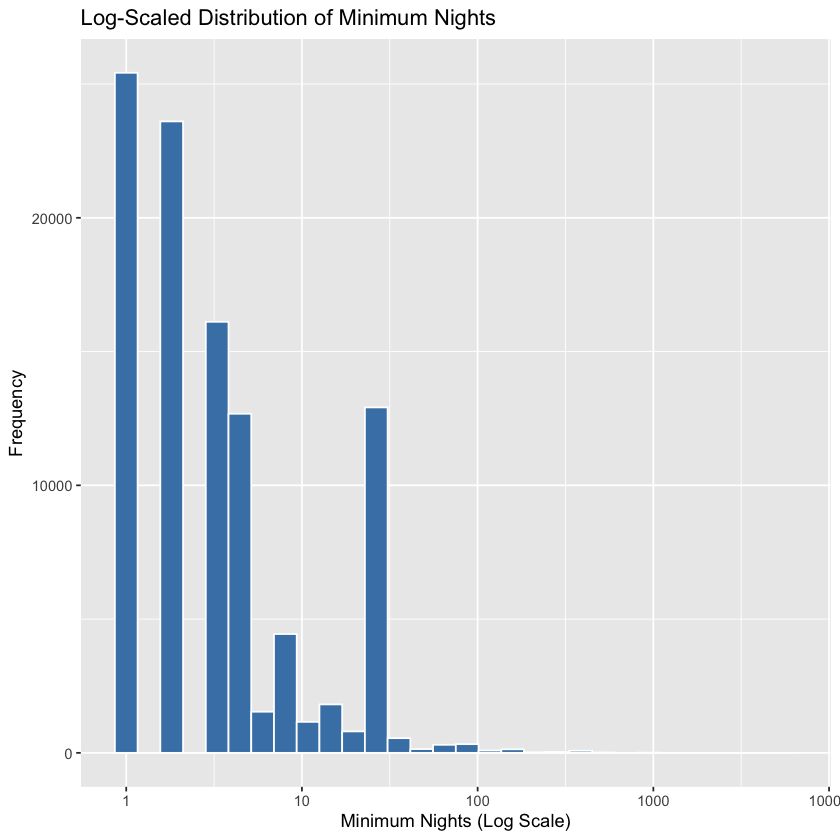

In [4]:
outlier_count <- sum(df$minimum.nights > 365, na.rm = TRUE)
print(outlier_count)
library(ggplot2)

ggplot(df, aes(x = minimum.nights)) +
  geom_histogram(bins = 30, fill = "steelblue", color = "white") +
  scale_x_log10() + # This is the magic line
  labs(title = "Log-Scaled Distribution of Minimum Nights",
       x = "Minimum Nights (Log Scale)",
       y = "Frequency")

[1] "Number of stays > 365 days: 35"


Warning message:
"Removed 409 rows containing missing values or values outside the scale range
(`geom_point()`)."


[1] 0


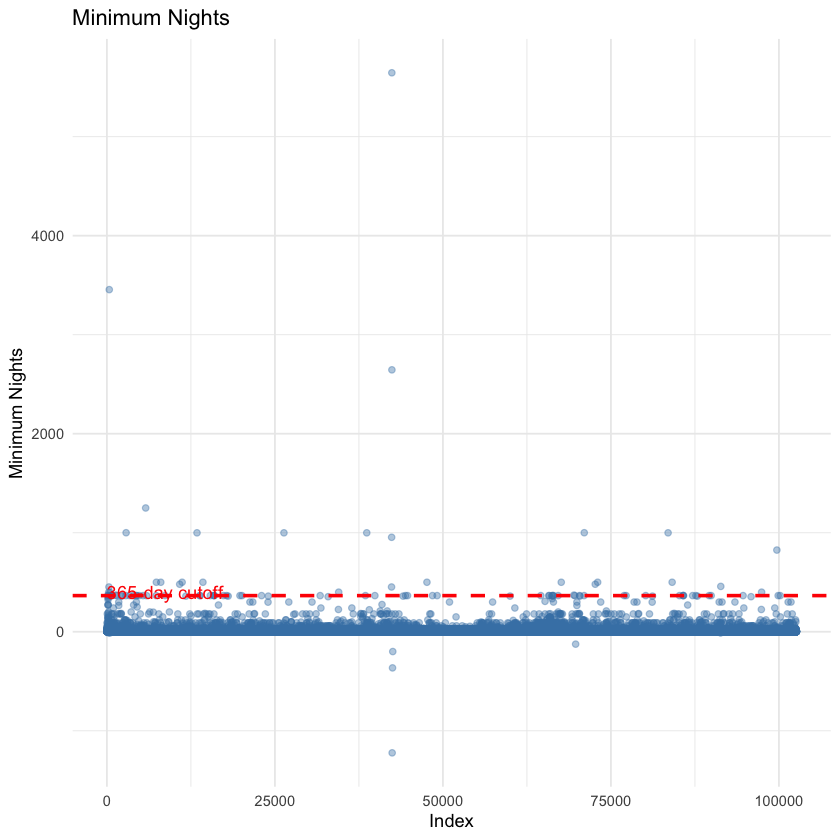

In [18]:
library(ggplot2)
library(dplyr)
df <- read.csv('/Users/arinapetushok/Documents/LSM2/airnbnb/Airbnb_Open_Data.csv')
outlier_count <- sum(df$minimum.nights > 365, na.rm = TRUE)
print(paste("Number of stays > 365 days:", outlier_count))
ggplot(df, aes(x = seq_along(minimum.nights), y = minimum.nights)) +
  geom_point(alpha = 0.4, color = "steelblue") +
  geom_hline(yintercept = 365, color = "red", linetype = "dashed", size = 1) +
  annotate("text", x = 0, y = 400, label = "365-day cutoff", color = "red", hjust = 0) +
  labs(title = "Minimum Nights ",
       x = "Index",
       y = "Minimum Nights") +
  theme_minimal()

df <- df %>%
  filter(minimum.nights <= 365)

outlier_count <- sum(df$minimum.nights > 365, na.rm = TRUE)
print(outlier_count)


In [25]:
df <- read.csv('/Users/arinapetushok/Documents/LSM2/airnbnb/Airbnb_Open_Data.csv')
df$minimum.nights
sum(df$minimum_nights == 'NA')

[1]    10    30     3    30    10     3    45    45     2     2     1     5
   [13]     2     4     2    90     2     2     1     3     7     3     2     1
   [25]     2     2     1     4    10     3    14     3     2     4     3     1
   [37]     4    60     2     1     1     2     3     7     4     7    NA    NA
   [49]    NA    NA    NA    NA    NA    NA    NA    NA    30     5     2     4
   [61]    30     2   180     2    30     7    30     3     1     1     1     4
   [73]     9     7     2     2     5     1    30     3     3     3    31     5
   [85]     6    30     1     3     3     1     3     4     4     7     7     5
   [97]    NA    NA    NA    NA    NA    NA    NA    NA    NA    NA    30    90
  [109]    30     2    30     2     2     7    30     2     5     3     6     1
  [121]     2     2     2     7     4     2     1     5    15     3     3     3
  [133]     5     3     3     2    29     2    NA    NA    NA    NA    NA    NA
  [145]    NA    NA    NA     4     3     3     8     4    15     3    15     2
  [157]    45     6     4     3     1     4    30     2    47    81   144   371
  [169]   149   273   131   275   323    59    99   268   -10   189    30   340
  [181]   128   350   166   110    57   142   366    NA    NA    NA    NA    NA
  [193]    NA    NA    14     1     1     2     5     2    30     7     7     2
  [205]     6    30     2     1     1     5     2     2     2     5     4     3
  [217]     1     2     1     2     2     3     3     3     2     3     1     2
  [229]     7     3    14     2     4    30     4     5    28     1     2     2
  [241]     4     3     2     2    14     4   200     3    50     3     2     2
  [253]     2     3     9     3     2     2     5     1    14     2     2   399
  [265]     5     3     7    17     3     3     4     6     2    14     2     2
  [277]     5     3     7    10    NA    NA    NA    NA    NA    NA    NA    NA
  [289]    NA    NA    NA    NA    NA     3     1    30     3    11     2   452
  [301]     2    30     5     2     3     2     3    25    30     1    30    13
  [313]     3     4     1    14    14     2     2     2     3     2     3     3
  [325]     4     6    14    NA    NA    NA    NA    NA    NA    NA    NA    NA
  [337]    NA    NA    30     2     3     5     1     3    15     2     5     3
  [349]     2     1  3455     2    -5    NA    NA    NA    NA    NA    NA    NA
  [361]     2     1     7     3    21     3     3     5    27    30     3     2
  [373]     3     5    18     7     1     2     2     2    10    14     1     6
  [385]    14     1   365     3    30     4     2     2     4     2     2     2
  [397]     2     2    -1     2     1    30     1     2     3     4     2     4
  [409]    10     2     3     4     7     5    20     3     2     2     3     1
  [421]     3   -10     4     8    NA    NA    NA    NA    NA    NA     3     2
  [433]     5     4     1     4     1     2     2     7     3   -12    40     2
  [445]     3     3    45    31     1     5     3     5     2     1     1     2
  [457]     3     2    40     6     3     5     2     3     5     2     4     2
  [469]     7     5    44    NA    NA   398    NA    NA    NA    NA    -2     3
  [481]    28     2    65     2     2     4     2     7     2     2     2     3
  [493]     5     3     3     2     2    30     3     4     4     2    10     6
  [505]     2     1    30    30     2     2    15     2     2     4    30     2
  [517]     1     6     3     1     1     4     3     4     7    -3     3     3
  [529]     3    28    30     2     6     6     1     1     1     1     3     1
  [541]     5     1     2     3     3     2     1    30     4     4    NA    NA
  [553]    NA    NA    NA     3     2     4     3     2    14     4     3     3
  [565]    28     3     1    90     2     7     1    30     2     3    30     2
  [577]    30     7     1     4     1     1     1     4     3     3     2    29
  [589]     3     2     4     5     1    55     4     4     3     3     1     6
  [6

[1] 0